# Testing the signal quality with Alphalens

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import seaborn as sns

from alphalens.tears import create_summary_tear_sheet, create_full_tear_sheet

from alphalens.utils import get_clean_factor_and_forward_returns

In [3]:
sns.set_style("whitegrid")

In [4]:
idx = pd.IndexSlice

In [5]:
results_path = Path("results", "return_predictions")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Evaluating the Cross-Validation Results

In [6]:
lookahead = 1

In [7]:
cv_store = Path(results_path / "parameter_tuning.h5")

### Get AlphaLens Input

In [8]:
DATA_DIR = Path("..", "data")

Using next available prices.

In [9]:
def get_trade_prices(tickers):
    store = DATA_DIR / "assets.h5"
    prices = pd.read_hdf(store, "stooq/jp/tse/stocks/prices")
    return (
        prices.loc[idx[tickers, "2014":"2019"], "open"]
        .unstack("ticker")
        .sort_index()
        .shift(-1)
        .dropna()
        .tz_localize("UTC")
    )

Reloading predictions.

In [10]:
best_predictions = pd.read_hdf(results_path / "predictions.h5", f"test/{lookahead:02}")
best_predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 472500 entries, ('9984.JP', Timestamp('2019-12-23 00:00:00')) to ('6490.JP', Timestamp('2017-12-15 00:00:00'))
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   y_test  472500 non-null  float64
 1   0       472500 non-null  float64
 2   1       472500 non-null  float64
 3   2       472500 non-null  float64
 4   3       472500 non-null  float64
 5   4       472500 non-null  float64
 6   5       472500 non-null  float64
 7   6       472500 non-null  float64
 8   7       472500 non-null  float64
 9   8       472500 non-null  float64
 10  9       472500 non-null  float64
dtypes: float64(11)
memory usage: 41.7+ MB


In [11]:
test_tickers = best_predictions.index.get_level_values("ticker").unique()

In [12]:
trade_prices = get_trade_prices(test_tickers)
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1464 entries, 2014-01-06 00:00:00+00:00 to 2019-12-27 00:00:00+00:00
Columns: 945 entries, 9984.JP to 6490.JP
dtypes: float64(945)
memory usage: 10.6 MB


In [13]:
factor = (
    best_predictions.iloc[:, :3]
    .mean(1)
    .tz_localize("UTC", level="date")
    .swaplevel()
    .dropna()
    .reset_index()
    .drop_duplicates()
    .set_index(["date", "ticker"])
)

In [14]:
factor_data = get_clean_factor_and_forward_returns(
    factor=factor, prices=trade_prices, quantiles=5, periods=(1, 5, 10, 21)
)
factor_data.sort_index().info()

Dropped 4.2% entries from factor data: 4.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 452655 entries, (Timestamp('2017-12-11 00:00:00+0000', tz='UTC'), '1301.JP') to (Timestamp('2019-11-28 00:00:00+0000', tz='UTC'), '9997.JP')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   1D               452655 non-null  float64
 1   5D               452655 non-null  float64
 2   10D              452655 non-null  float64
 3   21D              452655 non-null  float64
 4   factor           452655 non-null  float64
 5   factor_quantile  452655 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 22.5+ MB


### Summary Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.093207,0.013951,-0.008082,0.007895,90532,20.000221
2,-0.033307,0.017613,-0.003170,0.005734,90531,20.000000
3,-0.028911,0.021240,-0.000878,0.005533,90545,20.003093
4,-0.025582,0.026053,0.001435,0.005525,90523,19.998233
5,-0.020973,0.121495,0.006717,0.007795,90524,19.998454


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,54.859,1.153,0.454,0.191
beta,-0.024,-0.028,-0.018,-0.009
Mean Period Wise Return Top Quantile (bps),152.124,28.779,14.108,6.582
Mean Period Wise Return Bottom Quantile (bps),-148.020,-28.814,-14.075,-6.586
Mean Period Wise Spread (bps),300.144,57.597,28.187,13.170


Information Analysis


,1D,5D,10D,21D
IC Mean,0.670,0.281,0.196,0.132
IC Std.,0.098,0.119,0.121,0.116
Risk-Adjusted IC,6.836,2.371,1.625,1.134
t-stat(IC),149.624,51.886,35.574,24.810
p-value(IC),0.000,0.000,0.000,0.000
IC Skew,-1.676,-0.320,-0.312,-0.321
IC Kurtosis,5.694,0.567,0.698,1.023


Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.771,0.787,0.791,0.783
Quantile 2 Mean Turnover,0.786,0.793,0.795,0.794
Quantile 3 Mean Turnover,0.777,0.786,0.790,0.790
Quantile 4 Mean Turnover,0.790,0.795,0.796,0.795
Quantile 5 Mean Turnover,0.773,0.788,0.789,0.786


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,-0.002,-0.009,-0.012,0.005


<Figure size 640x480 with 0 Axes>

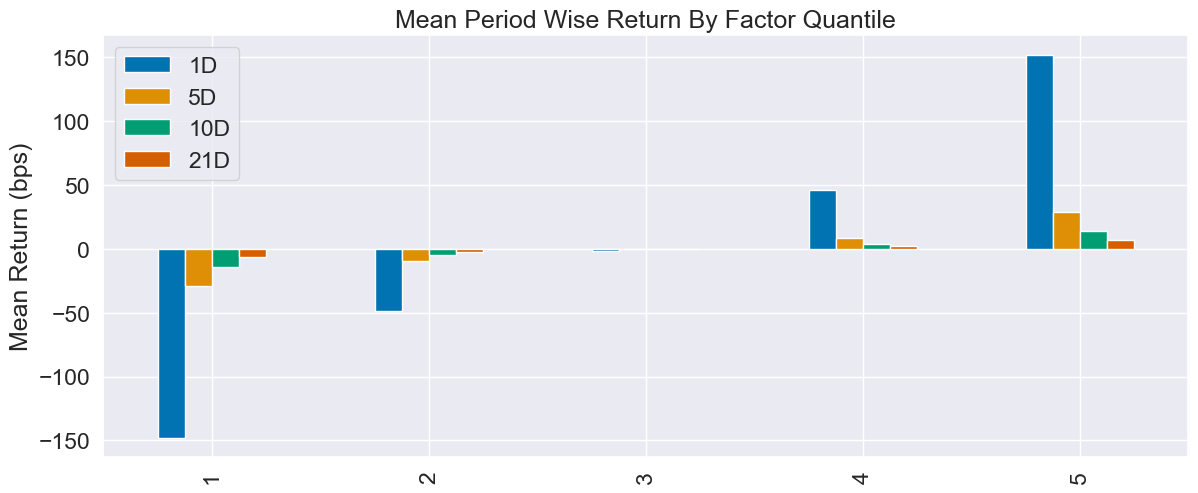

In [15]:
create_summary_tear_sheet(factor_data)

## Evaluating the Out-of-sample predictions

### Prepare Factor Data

In [16]:
t = 1
predictions = pd.read_hdf(results_path / "predictions.h5", f"test/{t:02}").drop(
    "y_test", axis=1
)

In [17]:
predictions.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 472500 entries, ('9984.JP', Timestamp('2019-12-23 00:00:00')) to ('6490.JP', Timestamp('2017-12-15 00:00:00'))
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       472500 non-null  float64
 1   1       472500 non-null  float64
 2   2       472500 non-null  float64
 3   3       472500 non-null  float64
 4   4       472500 non-null  float64
 5   5       472500 non-null  float64
 6   6       472500 non-null  float64
 7   7       472500 non-null  float64
 8   8       472500 non-null  float64
 9   9       472500 non-null  float64
dtypes: float64(10)
memory usage: 38.1+ MB


In [18]:
factor = (
    predictions.iloc[:, :10]
    .mean(1)
    .sort_index()
    .tz_localize("UTC", level="date")
    .swaplevel()
    .dropna()
)
factor.head()

date                       ticker 
2017-12-11 00:00:00+00:00  1301.JP    0.002043
2017-12-12 00:00:00+00:00  1301.JP   -0.002188
2017-12-13 00:00:00+00:00  1301.JP    0.001927
2017-12-14 00:00:00+00:00  1301.JP    0.000758
2017-12-15 00:00:00+00:00  1301.JP    0.000088
dtype: float64

### Select next available trade prices

Using next available prices.

In [19]:
tickers = factor.index.get_level_values("ticker").unique()
trade_prices = get_trade_prices(tickers)
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1464 entries, 2014-01-06 00:00:00+00:00 to 2019-12-27 00:00:00+00:00
Columns: 945 entries, 1301.JP to 9997.JP
dtypes: float64(945)
memory usage: 10.6 MB


### Get AlphaLens Inputs

In [20]:
factor_data = get_clean_factor_and_forward_returns(
    factor=factor, prices=trade_prices, quantiles=5, periods=(1, 5, 10, 21)
)
factor_data.sort_index().info()

Dropped 4.2% entries from factor data: 4.2% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 452655 entries, (Timestamp('2017-12-11 00:00:00+0000', tz='UTC'), '1301.JP') to (Timestamp('2019-11-28 00:00:00+0000', tz='UTC'), '9997.JP')
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   1D               452655 non-null  float64
 1   5D               452655 non-null  float64
 2   10D              452655 non-null  float64
 3   21D              452655 non-null  float64
 4   factor           452655 non-null  float64
 5   factor_quantile  452655 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 22.7+ MB


### Summary Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.038953,0.012141,-0.003289,0.005121,90531,20.0
2,-0.029609,0.012326,-0.002283,0.004756,90531,20.0
3,-0.029031,0.016155,-0.001681,0.004675,90531,20.0
4,-0.028473,0.017302,-0.001072,0.004673,90531,20.0
5,-0.027598,0.025104,0.000089,0.004871,90531,20.0


Returns Analysis


,1D,5D,10D,21D
Ann. alpha,0.041,0.012,0.007,0.022
beta,0.027,0.023,0.013,0.019
Mean Period Wise Return Top Quantile (bps),2.301,0.880,0.504,1.250
Mean Period Wise Return Bottom Quantile (bps),-1.135,-0.116,-0.193,-0.884
Mean Period Wise Spread (bps),3.437,0.992,0.699,2.134


Information Analysis


,1D,5D,10D,21D
IC Mean,0.007,0.005,0.007,0.019
IC Std.,0.108,0.112,0.112,0.111
Risk-Adjusted IC,0.066,0.044,0.063,0.171
t-stat(IC),1.443,0.972,1.388,3.749
p-value(IC),0.150,0.332,0.166,0.000
IC Skew,0.277,0.138,0.251,0.448
IC Kurtosis,1.532,0.706,0.684,0.854


Turnover Analysis


,1D,5D,10D,21D
Quantile 1 Mean Turnover,0.697,0.737,0.771,0.794
Quantile 2 Mean Turnover,0.767,0.782,0.791,0.797
Quantile 3 Mean Turnover,0.774,0.788,0.793,0.797
Quantile 4 Mean Turnover,0.769,0.784,0.789,0.799
Quantile 5 Mean Turnover,0.690,0.724,0.765,0.793


,1D,5D,10D,21D
Mean Factor Rank Autocorrelation,0.19,0.13,0.057,0.004


<Figure size 640x480 with 0 Axes>

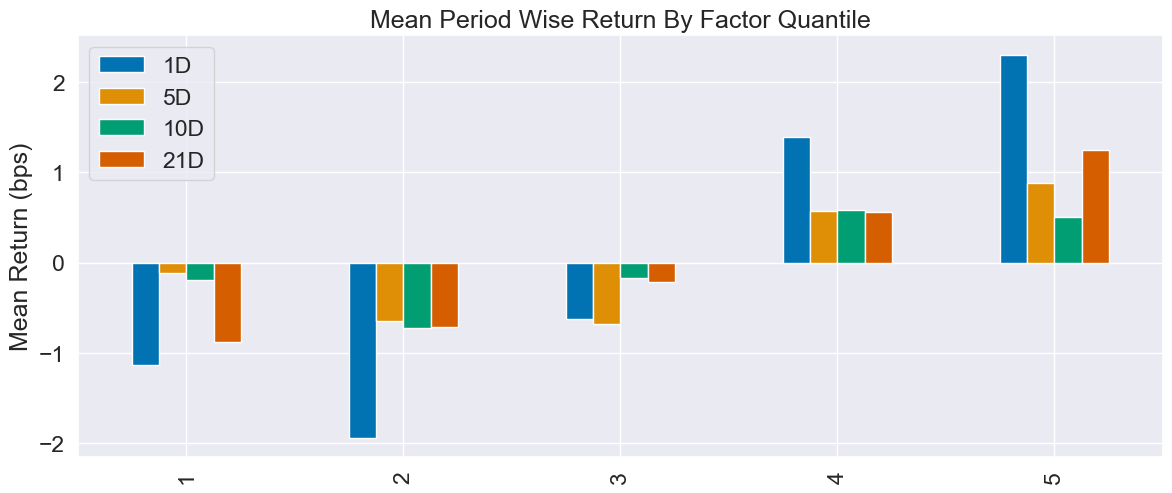

In [21]:
create_summary_tear_sheet(factor_data)